In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Load sample of transactions (1M rows for speed)
df = pd.read_csv('../data/raw/transactions_train.csv', 
                 parse_dates=['t_dat'],
                 nrows=1_000_000)

print("="*60)
print("PRICE DATA OVERVIEW")
print("="*60)
print(f"Sample size: {len(df):,} transactions")
print(f"\nPrice column info:")
print(df['price'].describe())
print(f"\nAny negative prices: {(df['price'] < 0).any()}")
print(f"Any zero prices: {(df['price'] == 0).sum():,}")
print(f"Missing prices: {df['price'].isnull().sum()}")

PRICE DATA OVERVIEW
Sample size: 1,000,000 transactions

Price column info:
count    1000000.000000
mean           0.030179
std            0.022913
min            0.000678
25%            0.016932
50%            0.025407
75%            0.033881
max            0.591525
Name: price, dtype: float64

Any negative prices: False
Any zero prices: 0
Missing prices: 0


In [6]:
# Random sample instead
df = pd.read_csv('../data/raw/transactions_train.csv',
                 parse_dates=['t_dat'],
                 skiprows=lambda i: i > 0 and np.random.random() > 0.05)  # ~5% random sample

print("="*60)
print("RANDOM SAMPLE - PRICE INVESTIGATION")
print("="*60)
print(f"Sample size: {len(df):,} transactions")
print(f"\nPrice statistics:")
print(df['price'].describe())

# Look at some actual transactions
print("\nRandom actual transactions:")
print(df[['t_dat', 'customer_id', 'article_id', 'price']].sample(10))

# Check if prices might be in a different unit
print(f"\nIf we multiply by 100 (convert to dollars):")
print(f"Mean: ${df['price'].mean() * 100:.2f}")
print(f"Median: ${df['price'].median() * 100:.2f}")
print(f"Range: ${df['price'].min() * 100:.2f} - ${df['price'].max() * 100:.2f}")

RANDOM SAMPLE - PRICE INVESTIGATION
Sample size: 1,589,397 transactions

Price statistics:
count    1.589397e+06
mean     2.783497e-02
std      1.920593e-02
min      1.864407e-04
25%      1.576271e-02
50%      2.540678e-02
75%      3.388136e-02
max      5.067797e-01
Name: price, dtype: float64

Random actual transactions:
             t_dat                                        customer_id  \
404364  2019-03-31  93d9f582c65071fd9c961f1911f39fd01f999d2f6dd787...   
871169  2019-10-02  ada4a16ce2c02b0f9b1f548bb7377e717ff605def7e1ac...   
653738  2019-07-01  65fef7b3cdf62ab6dba639616a2e7cfec4cefb44bfd5cd...   
809409  2019-09-03  6f37e9c3124c0ea78a6fc481329e0154cac05f25bd24ca...   
1369493 2020-06-17  82a540ab4f6ebf41aabd210fc1ab85357ca6c6e8178b4a...   
301691  2019-02-10  192d44e3f2a6ac91bc781048a797f8bc6cda1d2c453b40...   
1317836 2020-05-26  dc51294adf06c5d6edb864dc4f295a8977c26b9464f083...   
1387542 2020-06-22  4bd907822e837498d0ea6f6b14ed98d8644cc4ad0d5b64...   
1404288 2020-06-26 

In [8]:
print("="*60)
print("TESTING PRICE MULTIPLIERS")
print("="*60)

multipliers = [1, 10, 100, 1000]

for mult in multipliers:
    prices_adjusted = df['price'] * mult
    print(f"\nMultiplier: {mult}x")
    print(f"  Median: {prices_adjusted.median():.2f}")
    print(f"  Mean: {prices_adjusted.mean():.2f}")
    print(f"  25th percentile: {prices_adjusted.quantile(0.25):.2f}")
    print(f"  75th percentile: {prices_adjusted.quantile(0.75):.2f}")
    print(f"  Max: {prices_adjusted.max():.2f}")
    print(f"  → Does this match typical H&M prices in SEK?")

TESTING PRICE MULTIPLIERS

Multiplier: 1x
  Median: 0.03
  Mean: 0.03
  25th percentile: 0.02
  75th percentile: 0.03
  Max: 0.51
  → Does this match typical H&M prices in SEK?

Multiplier: 10x
  Median: 0.25
  Mean: 0.28
  25th percentile: 0.16
  75th percentile: 0.34
  Max: 5.07
  → Does this match typical H&M prices in SEK?

Multiplier: 100x
  Median: 2.54
  Mean: 2.78
  25th percentile: 1.58
  75th percentile: 3.39
  Max: 50.68
  → Does this match typical H&M prices in SEK?

Multiplier: 1000x
  Median: 25.41
  Mean: 27.83
  25th percentile: 15.76
  75th percentile: 33.88
  Max: 506.78
  → Does this match typical H&M prices in SEK?


Removed 15,892 outliers (>0.1003)
Working with 1,573,505 transactions


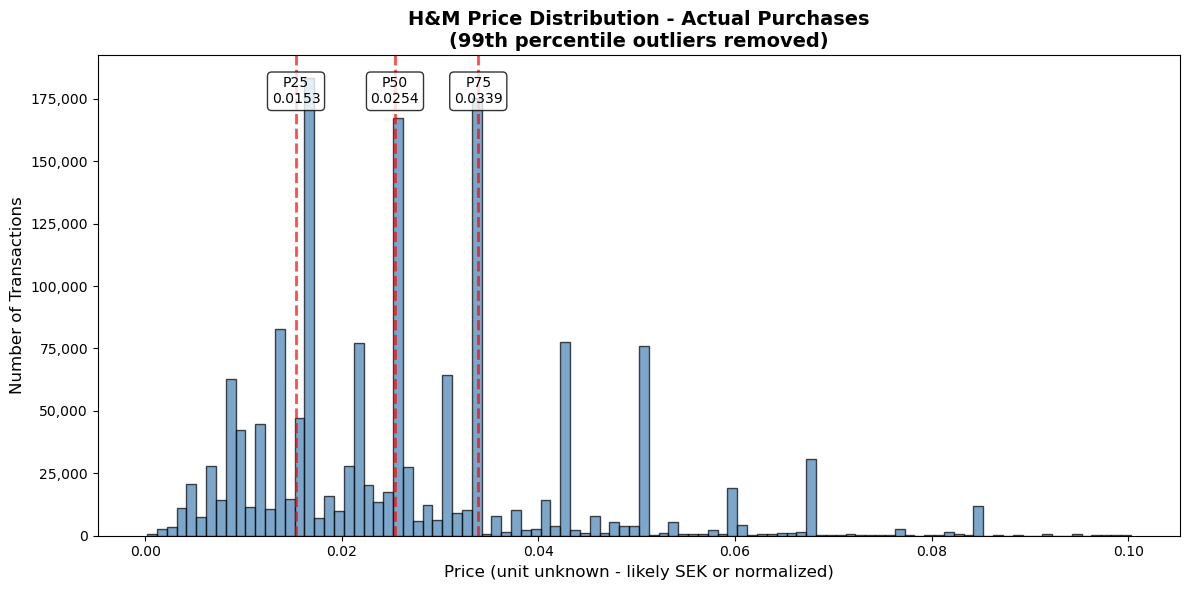


PRICE DISTRIBUTION SUMMARY
Median price: 0.0254
Mean price: 0.0268
25th percentile: 0.0153
75th percentile: 0.0339
Interquartile range: 0.0185


In [10]:
# Remove extreme outliers (top 1% - likely errors or returns)
price_99 = df['price'].quantile(0.99)
df_clean = df[df['price'] <= price_99].copy()

print(f"Removed {len(df) - len(df_clean):,} outliers (>{price_99:.4f})")
print(f"Working with {len(df_clean):,} transactions")

# Create the visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Histogram
ax.hist(df_clean['price'], bins=100, edgecolor='black', alpha=0.7, color='steelblue')

# Mark key percentiles
percentiles = [25, 50, 75]
for p in percentiles:
    val = df_clean['price'].quantile(p/100)
    ax.axvline(val, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax.text(val, ax.get_ylim()[1]*0.9, f'P{p}\n{val:.4f}', 
            ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Price (unit unknown - likely SEK or normalized)', fontsize=12)
ax.set_ylabel('Number of Transactions', fontsize=12)
ax.set_title('H&M Price Distribution - Actual Purchases\n(99th percentile outliers removed)', 
             fontsize=14, fontweight='bold')

# Format y-axis with commas
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../visualizations/day4_price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("PRICE DISTRIBUTION SUMMARY")
print("="*60)
print(f"Median price: {df_clean['price'].median():.4f}")
print(f"Mean price: {df_clean['price'].mean():.4f}")
print(f"25th percentile: {df_clean['price'].quantile(0.25):.4f}")
print(f"75th percentile: {df_clean['price'].quantile(0.75):.4f}")
print(f"Interquartile range: {df_clean['price'].quantile(0.75) - df_clean['price'].quantile(0.25):.4f}")

H&M's price distribution shows strong concentration, with 50% of all purchases 
falling within a narrow price band (P25=0.0153 to P75=0.0339, IQR=0.0185). 
The distribution is right-skewed with a clear peak around the median (0.0254), 
indicating most transaction volume occurs at lower price points while a long tail 
of higher-priced items exists but represents fewer transactions. Without knowing 
the actual currency unit or comparing to H&M's full catalog pricing, we cannot 
determine if this reflects strategic pricing decisions, customer preferences for 
certain product categories, or discount/sale patterns.